# Sparkline Generator

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/analytics-engineering-bi/sparkline-gen/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=analytics-engineering-bi/sparkline-gen/demo.ipynb)

> A sparkline is a chart. Every failure mode of a chart applies to it - but at 80x20 pixels,
> inside a table cell, nobody audits it. **The default one-liner autoscales each row to its own
> min and max, which makes a row that grew 1% and a row that grew 9,900% into the same picture.**

**What this covers**

1. What a sparkline is, and the four decisions hiding inside it
2. **The main event**: per-row autoscale emits byte-identical paths for data 2,000,000x apart
3. The cell's aspect ratio, not the data, sets the perceived trend
4. A gap drawn through is invented data at full stroke weight
5. Endpoints vs a robust trend - and why the right answer depends on a noise model
6. Irregular time plotted at equal steps is a different series
7. SVG mechanics at 20 pixels tall: clipping, stroke scaling, byte budget, escaping
8. The verdict the tool is entitled to print
9. Try your own table

*Fully offline - all data is generated, standard library plus numpy and matplotlib.*

## 0. Setup

`sparkline.py` has no dependencies beyond the standard library. numpy and matplotlib are used
only for the experiments and the charts.

In [1]:
import pathlib

SPARKLINE_SRC = r'''"""Sparkline generation with the scale, geometry and gap decisions made explicit.

A sparkline is a chart. Every failure mode of a chart applies to it - but at 60x18 pixels,
inside a table cell, nobody audits it. This module makes the four decisions that decide
whether a sparkline tells the truth into named, inspectable parameters:

  1. SCALE     - per-row autoscale destroys cross-row comparability (`resolve_domain`)
  2. GEOMETRY  - the cell's aspect ratio, not the data, sets perceived steepness (`banked_width`)
  3. GAPS      - a missing value drawn through is an invented trend (`build_path`)
  4. TIME      - unequal spacing plotted at equal x-intervals is a different series (`x_positions`)

Plus the SVG mechanics that silently corrupt output at this size: half-stroke clipping,
stroke scaling under a viewBox, coordinate precision as a byte budget, and label escaping.

No dependencies beyond the standard library. numpy/matplotlib are only used by the
experiment and chart modules.
"""

from __future__ import annotations

import math
from dataclasses import dataclass, field
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

Number = Optional[float]

# --------------------------------------------------------------------------------------
# Scale policies
# --------------------------------------------------------------------------------------

#: Every scale mode this module knows about, with the question each one answers.
SCALE_MODES: Dict[str, str] = {
    "per_row": "each row scaled to its own min/max - shape only, NOT comparable across rows",
    "shared": "one min/max across all rows - rows comparable, small rows may flatten",
    "shared_zero": "shared, with the domain forced to include 0 - level readable",
    "indexed": "each row divided by its own first value - comparable as percent change",
}

COMPARABLE_MODES = frozenset({"shared", "shared_zero", "indexed"})


@dataclass(frozen=True)
class Domain:
    """The vertical extent a sparkline is drawn against, and where it came from."""

    lo: float
    hi: float
    mode: str
    degenerate: bool = False

    @property
    def span(self) -> float:
        return self.hi - self.lo


@dataclass
class Series:
    """One row of a table: a label, values (None = missing), optional real time positions."""

    label: str
    values: Sequence[Number]
    times: Optional[Sequence[float]] = None

    def __post_init__(self) -> None:
        if self.times is not None and len(self.times) != len(self.values):
            raise ValueError(
                "times has length %d but values has length %d"
                % (len(self.times), len(self.values))
            )
        if self.times is not None and any(
            self.times[i + 1] <= self.times[i] for i in range(len(self.times) - 1)
        ):
            raise ValueError("times must be strictly increasing")

    @property
    def present(self) -> List[float]:
        """Non-missing values, in order."""
        return [float(v) for v in self.values if v is not None]

    @property
    def n_missing(self) -> int:
        return sum(1 for v in self.values if v is None)


def resolve_domain(
    series: Series,
    mode: str = "per_row",
    table: Optional[Sequence[Series]] = None,
    pad_frac: float = 0.0,
) -> Domain:
    """Return the (lo, hi) this series should be drawn against under `mode`.

    `table` is required for the shared modes - that is the entire point of them, and
    silently falling back to per-row when it is missing is how a comparable table stops
    being comparable without anyone noticing. So it raises instead.
    """
    if mode not in SCALE_MODES:
        raise ValueError("unknown scale mode %r; expected one of %s" % (mode, sorted(SCALE_MODES)))

    if mode == "per_row":
        pool = series.present
    elif mode == "indexed":
        pool = [v for s in (table or [series]) for v in _index_to_first(s)]
    else:
        if table is None:
            raise ValueError(
                "mode=%r needs the whole table to compute a shared domain; "
                "pass table=[...] or use mode='per_row' and label it as non-comparable" % mode
            )
        pool = [v for s in table for v in s.present]

    if not pool:
        return Domain(0.0, 1.0, mode, degenerate=True)

    lo, hi = min(pool), max(pool)
    if mode == "shared_zero":
        lo, hi = min(lo, 0.0), max(hi, 0.0)

    if hi == lo:
        # A flat series has no extent. Manufacturing one by expanding the domain would
        # turn rounding noise into a visible trend, so it is flagged and drawn flat.
        return Domain(lo, hi, mode, degenerate=True)

    if pad_frac:
        pad = (hi - lo) * pad_frac
        lo, hi = lo - pad, hi + pad
    return Domain(lo, hi, mode)


def _index_to_first(series: Series) -> List[float]:
    """Values as a ratio to the first present value. Empty if that value is 0 or absent."""
    present = series.present
    if not present or present[0] == 0:
        return []
    base = present[0]
    return [float(v) / base for v in series.values if v is not None]


def indexed_series(series: Series) -> Series:
    """`series` rebased so its first present value is 1.0, preserving gaps and times."""
    present = series.present
    if not present or present[0] == 0:
        raise ValueError(
            "cannot index %r: first present value is %s"
            % (series.label, present[0] if present else "missing")
        )
    base = present[0]
    return Series(
        series.label,
        [None if v is None else float(v) / base for v in series.values],
        series.times,
    )


# --------------------------------------------------------------------------------------
# Geometry
# --------------------------------------------------------------------------------------


@dataclass(frozen=True)
class Geometry:
    """Rendered pixel box. `pad` exists so a stroke at the domain edge is not half-clipped."""

    width: float = 80.0
    height: float = 20.0
    stroke: float = 1.25
    dot: float = 0.0  # endpoint marker radius; 0 = no marker

    @property
    def pad(self) -> float:
        # Half the stroke keeps the line inside the viewBox. A marker needs its full radius.
        return max(self.stroke / 2.0, self.dot)

    @property
    def inner_w(self) -> float:
        return max(self.width - 2 * self.pad, 1e-9)

    @property
    def inner_h(self) -> float:
        return max(self.height - 2 * self.pad, 1e-9)

    @property
    def aspect(self) -> float:
        return self.width / self.height


def x_positions(series: Series, geom: Geometry, use_times: bool = True) -> List[float]:
    """Horizontal pixel position per index.

    With `use_times=False` (or no times) points are equally spaced by index - which redraws
    an irregular series as a regular one. `experiment_time_axis` measures what that costs.
    """
    n = len(series.values)
    if n == 0:
        return []
    if n == 1:
        return [geom.pad + geom.inner_w / 2.0]

    if use_times and series.times is not None:
        t0, t1 = float(series.times[0]), float(series.times[-1])
        span = t1 - t0
        if span <= 0:
            return [geom.pad + geom.inner_w / 2.0] * n
        return [geom.pad + (float(t) - t0) / span * geom.inner_w for t in series.times]

    return [geom.pad + i / (n - 1) * geom.inner_w for i in range(n)]


def y_position(value: float, domain: Domain, geom: Geometry) -> float:
    """Vertical pixel position. SVG y grows downward, so the domain is flipped."""
    if domain.degenerate:
        return geom.pad + geom.inner_h / 2.0
    frac = (float(value) - domain.lo) / domain.span
    frac = min(max(frac, 0.0), 1.0)  # clamp: out-of-domain rows must not draw outside the cell
    return geom.pad + (1.0 - frac) * geom.inner_h


def segment_slopes_deg(points: Sequence[Tuple[float, float]]) -> List[float]:
    """Signed slope of each drawn segment, in degrees, in *rendered pixel space*.

    This is the quantity the reader's eye actually integrates. It depends on the cell's
    width and height, which is why the same data can read as flat or as a crisis.
    """
    out: List[float] = []
    for (x0, y0), (x1, y1) in zip(points, points[1:]):
        dx = x1 - x0
        if dx <= 0:
            continue
        out.append(math.degrees(math.atan2(-(y1 - y0), dx)))  # -dy: screen y is inverted
    return out


def banking_deg(points: Sequence[Tuple[float, float]]) -> float:
    """Median absolute rendered slope. Cleveland: slope judgement is best near 45 degrees."""
    slopes = [abs(s) for s in segment_slopes_deg(points)]
    return _median(slopes) if slopes else 0.0


def banked_width(series: Series, domain: Domain, geom: Geometry, target_deg: float = 45.0) -> float:
    """The width at which this series banks to `target_deg` at `geom`'s height.

    tan is monotone on [0, 90), so median(tan theta) == tan(median theta) exactly, and the
    solve is closed-form: horizontal spacing is proportional to width while vertical
    excursions are fixed by the height and the domain.
    """
    xs = x_positions(series, geom)
    ys = [None if v is None else y_position(v, domain, geom) for v in series.values]
    dys, dxs = [], []
    for i in range(len(ys) - 1):
        if ys[i] is None or ys[i + 1] is None:
            continue
        dys.append(abs(ys[i + 1] - ys[i]))
        dxs.append(xs[i + 1] - xs[i])
    if not dys or _median(dys) == 0:
        return geom.width
    # dx scales with inner_w, so the needed inner_w multiplies by the ratio of tangents.
    ratio = (_median(dys) / _median(dxs)) / math.tan(math.radians(target_deg))
    return geom.pad * 2 + geom.inner_w * ratio


def _median(xs: Sequence[float]) -> float:
    s = sorted(xs)
    n = len(s)
    if n == 0:
        raise ValueError("median of empty sequence")
    mid = n // 2
    return s[mid] if n % 2 else (s[mid - 1] + s[mid]) / 2.0


# --------------------------------------------------------------------------------------
# Trend: what the endpoints say vs what the series does
# --------------------------------------------------------------------------------------


def endpoint_direction(series: Series) -> int:
    """sign(last - first). The statistic a sparkline invites, using 2 of n points."""
    present = series.present
    if len(present) < 2:
        return 0
    d = present[-1] - present[0]
    return (d > 0) - (d < 0)


def theil_sen_slope(series: Series, use_times: bool = True) -> float:
    """Median of all pairwise slopes - a breakdown-point-0.29 robust trend estimate."""
    pts = [
        (float(series.times[i]) if (use_times and series.times is not None) else float(i), float(v))
        for i, v in enumerate(series.values)
        if v is not None
    ]
    if len(pts) < 2:
        return 0.0
    slopes = [
        (pts[j][1] - pts[i][1]) / (pts[j][0] - pts[i][0])
        for i in range(len(pts))
        for j in range(i + 1, len(pts))
        if pts[j][0] != pts[i][0]
    ]
    return _median(slopes) if slopes else 0.0


def trend_direction(series: Series, use_times: bool = True) -> int:
    s = theil_sen_slope(series, use_times)
    return (s > 0) - (s < 0)


# --------------------------------------------------------------------------------------
# Path construction
# --------------------------------------------------------------------------------------


@dataclass
class Path:
    """A rendered path plus the accounting needed to describe what was drawn."""

    d: str
    points: List[Tuple[float, float]]
    n_subpaths: int
    n_isolated: int
    bridged_gaps: int = 0


def build_path(
    series: Series,
    domain: Domain,
    geom: Geometry,
    bridge_gaps: bool = False,
    precision: int = 2,
    use_times: bool = True,
) -> Path:
    """Turn a series into an SVG path `d`.

    With `bridge_gaps=False` (the default and the correct one) a missing value ends the
    subpath and the next present value starts a new `M`. The gap renders as a gap.

    With `bridge_gaps=True` - which is what every one-liner does, because it drops the NaNs
    and plots what is left - the two endpoints of the gap are joined by a straight line. That
    line is drawn at full stroke weight, indistinguishable from measured data, and it is
    always monotone, so a gap over a dip renders as a clean trend.

    A run of exactly one present value between two gaps cannot be stroked (a zero-length
    path draws nothing under `stroke-linecap: butt`), so it is emitted as a dot. Otherwise
    isolated observations vanish silently.
    """
    xs = x_positions(series, geom, use_times=use_times)
    pts: List[Optional[Tuple[float, float]]] = [
        None if v is None else (xs[i], y_position(float(v), domain, geom))
        for i, v in enumerate(series.values)
    ]

    runs: List[List[Tuple[float, float]]] = []
    current: List[Tuple[float, float]] = []
    for p in pts:
        if p is None:
            if current:
                runs.append(current)
                current = []
        else:
            current.append(p)
    if current:
        runs.append(current)

    if bridge_gaps and len(runs) > 1:
        bridged = len(runs) - 1
        runs = [[p for run in runs for p in run]]
    else:
        bridged = 0

    parts: List[str] = []
    isolated = 0
    for run in runs:
        if len(run) == 1:
            x, y = run[0]
            r = max(geom.stroke / 2.0, 0.6)
            # A degenerate arc: two half-circles. Cheaper in bytes than a <circle> element
            # and it stays inside the single `d` attribute.
            parts.append(
                "M%s,%s a%s,%s 0 1,0 %s,0 a%s,%s 0 1,0 -%s,0"
                % (
                    _f(x - r, precision), _f(y, precision),
                    _f(r, precision), _f(r, precision), _f(2 * r, precision),
                    _f(r, precision), _f(r, precision), _f(2 * r, precision),
                )
            )
            isolated += 1
        else:
            head = "M%s,%s" % (_f(run[0][0], precision), _f(run[0][1], precision))
            tail = " ".join("%s,%s" % (_f(x, precision), _f(y, precision)) for x, y in run[1:])
            parts.append(head + " L" + tail)

    return Path(
        d=" ".join(parts),
        points=[p for run in runs for p in run],
        n_subpaths=len(runs),
        n_isolated=isolated,
        bridged_gaps=bridged,
    )


def _f(v: float, precision: int) -> str:
    """Format a coordinate. Trailing zeros and a bare `.0` are pure byte tax at this size."""
    s = ("%." + str(precision) + "f") % v
    if "." in s:
        s = s.rstrip("0").rstrip(".")
    return s or "0"


# --------------------------------------------------------------------------------------
# SVG emission
# --------------------------------------------------------------------------------------

_ESCAPES = (("&", "&amp;"), ("<", "&lt;"), (">", "&gt;"), ('"', "&quot;"), ("'", "&#39;"))


def escape(text: object) -> str:
    """Escape for both attribute and text contexts. Labels come from data; data is hostile."""
    s = str(text)
    for a, b in _ESCAPES:
        s = s.replace(a, b)
    return s


@dataclass
class Style:
    color: str = "#1f4e79"
    band_color: str = "#e8eef5"
    dot_color: str = "#c0392b"
    zero_color: str = "#9aa5b1"
    non_scaling_stroke: bool = True


def sparkline_svg(
    series: Series,
    domain: Domain,
    geom: Geometry = Geometry(),
    style: Style = Style(),
    bridge_gaps: bool = False,
    precision: int = 2,
    use_times: bool = True,
    show_zero: bool = False,
    responsive: bool = False,
) -> str:
    """One inline SVG sparkline.

    `responsive=True` drops the width/height attributes so the SVG fills its cell. That is
    usually what you want in a table and it is also what makes `stroke-width` scale with the
    cell - a 1.25px line becomes 3px in a wide column and 0.4px in a narrow one, so the
    *same data* reads as bolder in one place than another. `vector-effect="non-scaling-stroke"`
    pins the stroke to device pixels and is the only reason responsive mode is safe.
    """
    path = build_path(
        series, domain, geom, bridge_gaps=bridge_gaps, precision=precision, use_times=use_times
    )

    dims = "" if responsive else ' width="%s" height="%s"' % (_f(geom.width, 2), _f(geom.height, 2))
    vec = ' vector-effect="non-scaling-stroke"' if style.non_scaling_stroke else ""
    title = escape("%s (%s)" % (series.label, domain.mode))

    body: List[str] = []
    if show_zero and not domain.degenerate and domain.lo <= 0.0 <= domain.hi:
        yz = _f(y_position(0.0, domain, geom), precision)
        body.append(
            '<line x1="%s" y1="%s" x2="%s" y2="%s" stroke="%s" stroke-width="0.5" '
            'stroke-dasharray="2 2"/>'
            % (_f(geom.pad, 2), yz, _f(geom.width - geom.pad, 2), yz, style.zero_color)
        )
    body.append(
        '<path d="%s" fill="none" stroke="%s" stroke-width="%s" stroke-linecap="round" '
        'stroke-linejoin="round"%s/>' % (path.d, style.color, _f(geom.stroke, 2), vec)
    )
    if geom.dot > 0 and path.points:
        x, y = path.points[-1]
        body.append(
            '<circle cx="%s" cy="%s" r="%s" fill="%s"/>'
            % (_f(x, precision), _f(y, precision), _f(geom.dot, 2), style.dot_color)
        )

    return (
        '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 %s %s"%s '
        'role="img" aria-label="%s" preserveAspectRatio="none">'
        "<title>%s</title>%s</svg>"
        % (_f(geom.width, 2), _f(geom.height, 2), dims, title, title, "".join(body))
    )


# --------------------------------------------------------------------------------------
# Table rendering + the verdict
# --------------------------------------------------------------------------------------


@dataclass
class Verdict:
    """What the reader is entitled to conclude from the rendered table."""

    comparable: bool
    mode: str
    warnings: List[str] = field(default_factory=list)
    notes: List[str] = field(default_factory=list)

    def text(self) -> str:
        head = (
            "COMPARABLE ACROSS ROWS (mode=%s)" % self.mode
            if self.comparable
            else "NOT COMPARABLE ACROSS ROWS (mode=%s) - shape only" % self.mode
        )
        lines = [head]
        lines += ["  WARNING: " + w for w in self.warnings]
        lines += ["  note:    " + n for n in self.notes]
        return "\n".join(lines)


def audit_table(
    table: Sequence[Series],
    mode: str = "per_row",
    geom: Geometry = Geometry(),
    bridge_gaps: bool = False,
) -> Verdict:
    """Check a table of series against the four decisions before anything is rendered."""
    comparable = mode in COMPARABLE_MODES
    v = Verdict(comparable=comparable, mode=mode)

    magnitudes = [max(s.present) for s in table if s.present]
    if magnitudes and min(magnitudes) > 0:
        spread = max(magnitudes) / min(magnitudes)
        if not comparable and spread >= 10:
            v.warnings.append(
                "row maxima span %.0fx (%.3g to %.3g) yet every row is autoscaled to fill the "
                "cell - two rows with identical shapes differ in level by that factor"
                % (spread, min(magnitudes), max(magnitudes))
            )
        if comparable and mode != "indexed" and spread >= 50:
            v.notes.append(
                "row maxima span %.0fx; under a shared domain the small rows will render as "
                "flat lines. mode='indexed' compares percent change instead" % spread
            )

    gapped = [s for s in table if s.n_missing]
    if gapped and bridge_gaps:
        v.warnings.append(
            "%d of %d rows %s missing values and bridge_gaps=True - the interpolated "
            "segments are drawn at full stroke weight and cannot be told from measurements"
            % (len(gapped), len(table), "has" if len(gapped) == 1 else "have")
        )
    elif gapped:
        v.notes.append(
            "%d of %d rows %s missing values, rendered as breaks in the line"
            % (len(gapped), len(table), "has" if len(gapped) == 1 else "have")
        )

    irregular = [s for s in table if s.times is not None and not _is_regular(s.times)]
    if irregular:
        v.notes.append(
            "%s irregular time spacing; positions are taken from `times`, not the index "
            "(pass use_times=False to see what index spacing would have drawn)"
            % _n(len(irregular), "row has", "rows have")
        )
    undated = [s for s in table if s.times is None and s.n_missing == 0]
    if len(undated) == len(table) and table:
        v.notes.append("no `times` given - x positions assume equally spaced observations")

    disagree = [s.label for s in table if _endpoint_disagrees(s)]
    if disagree:
        v.warnings.append(
            "%s sign(last - first) disagreeing with the robust trend: %s. The endpoints are "
            "the noisiest reading of a sparkline and the one it invites"
            % (_n(len(disagree), "row has", "rows have"),
               ", ".join(disagree[:4]) + (" ..." if len(disagree) > 4 else ""))
        )

    flat = [s.label for s in table if s.present and max(s.present) == min(s.present)]
    if flat:
        v.notes.append(
            "%s drawn as a flat mid-height line rather than expanded to fill the cell: %s"
            % (_n(len(flat), "constant row"), ", ".join(flat[:4]))
        )

    banks = []
    for s in table:
        if len(s.present) < 2:
            continue
        d = resolve_domain(s, mode if comparable else "per_row", table=table)
        p = build_path(s, d, geom)
        if len(p.points) >= 2:
            banks.append(banking_deg(p.points))
    if banks:
        med = _median(banks)
        if med < 15 or med > 75:
            v.notes.append(
                "median rendered slope is %.0f degrees at %.0fx%.0f; slope judgement is most "
                "accurate near 45. Try banked_width() for a cell that suits the data"
                % (med, geom.width, geom.height)
            )
    return v


def _n(count: int, noun: str, plural: Optional[str] = None) -> str:
    """"1 row" / "3 rows". Audit text is read by people; "1 rows" undercuts it."""
    return "%d %s" % (count, noun if count == 1 else (plural or noun + "s"))


def _is_regular(times: Sequence[float], tol: float = 1e-6) -> bool:
    if len(times) < 3:
        return True
    gaps = [times[i + 1] - times[i] for i in range(len(times) - 1)]
    return (max(gaps) - min(gaps)) <= tol * max(1.0, max(gaps))


def _endpoint_disagrees(series: Series) -> bool:
    e, t = endpoint_direction(series), trend_direction(series)
    return e != 0 and t != 0 and e != t


def render_table(
    table: Sequence[Series],
    mode: str = "shared",
    geom: Geometry = Geometry(),
    style: Style = Style(),
    bridge_gaps: bool = False,
    precision: int = 2,
    show_zero: bool = False,
    banner: bool = True,
) -> str:
    """A full HTML table with sparklines, a printed domain, and the audit verdict inline.

    The printed domain is not decoration. A shared-scale sparkline is unreadable without it -
    the reader has no way to know whether a flat line means "stable" or "small relative to
    row 3", and a per-row-scale table without the label is actively misleading.
    """
    verdict = audit_table(table, mode=mode, geom=geom, bridge_gaps=bridge_gaps)
    rows: List[str] = []
    for s in table:
        drawn = indexed_series(s) if mode == "indexed" and s.present and s.present[0] else s
        d = resolve_domain(drawn, mode, table=table)
        svg = sparkline_svg(
            drawn, d, geom, style, bridge_gaps=bridge_gaps, precision=precision,
            show_zero=show_zero,
        )
        last = drawn.present[-1] if drawn.present else float("nan")
        rows.append(
            "<tr><td>%s</td><td>%s</td><td class='num'>%.3g</td>"
            "<td class='num'>%.3g – %.3g</td></tr>"
            % (escape(s.label), svg, last, d.lo, d.hi)
        )

    banner_class = "ok" if verdict.comparable else "warn"
    detail = "".join("<li>%s</li>" % escape(x) for x in verdict.warnings + verdict.notes)
    banner_html = (
        "<div class='banner %s'><b>%s</b><ul>%s</ul></div>"
        % (banner_class, escape(verdict.text().splitlines()[0]), detail)
        if banner
        else ""
    )
    return (
        "<style>"
        "table.spark{border-collapse:collapse;font:13px -apple-system,system-ui,sans-serif}"
        "table.spark td,table.spark th{padding:4px 10px;border-bottom:1px solid #e5e7eb}"
        "table.spark td.num{text-align:right;font-variant-numeric:tabular-nums;color:#4b5563}"
        ".banner{font:12px ui-monospace,monospace;padding:6px 10px;margin-bottom:8px;"
        "border-radius:4px}.banner.ok{background:#ecfdf5;color:#065f46}"
        ".banner.warn{background:#fef2f2;color:#991b1b}"
        ".banner ul{margin:6px 0 0 16px;padding:0}"
        "</style>"
        "%s"
        "<table class='spark'><tr><th>row</th><th>trend</th><th>last</th>"
        "<th>domain drawn against</th></tr>%s</table>"
        % (banner_html, "".join(rows))
    )


# --------------------------------------------------------------------------------------
# Sample data
# --------------------------------------------------------------------------------------


def sample_table() -> List[Series]:
    """Six rows of plausible weekly SaaS telemetry, each carrying a different lesson.

    Deterministic - no RNG, so every number in the README is reproducible by reading this.
    """
    return [
        # Two rows with the SAME shape and a 1000x difference in level. Under per-row
        # autoscale they render as identical paths.
        Series("enterprise_mrr", [402.0, 404.0, 406.0, 408.0, 410.0, 412.0, 414.0, 416.0]),
        Series("self_serve_mrr", [0.402, 0.404, 0.406, 0.408, 0.410, 0.412, 0.414, 0.416]),
        # Endpoints say up; the series spent the whole quarter falling and bounced once.
        Series("active_seats", [980.0, 940.0, 900.0, 860.0, 820.0, 790.0, 760.0, 1010.0]),
        # An outage window: the values are unknown, not zero.
        Series("api_p95_ms", [120.0, 128.0, 133.0, None, None, 210.0, 205.0, 199.0]),
        # Irregular reporting - the last two points are 6 weeks apart, not 1.
        Series(
            "nps",
            [31.0, 33.0, 34.0, 36.0, 41.0],
            times=[0.0, 1.0, 2.0, 3.0, 9.0],
        ),
        # Constant. Any autoscale that expands the domain turns this into a story.
        Series("uptime_pct", [99.99] * 8),
    ]
'''

EVIDENCE_SRC = r'''"""The six experiments the README quotes. Every one is seeded and runnable.

Each function returns a plain dict of measurements and prints a table. Nothing here reads a
file or a network - the data is generated so the numbers reproduce exactly.

Run all of them:  python3 evidence.py
"""

from __future__ import annotations

import math
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np

from sparkline import (
    Geometry,
    Series,
    Style,
    banked_width,
    banking_deg,
    build_path,
    endpoint_direction,
    indexed_series,
    resolve_domain,
    sparkline_svg,
    theil_sen_slope,
    trend_direction,
    y_position,
)

RULE = "-" * 86


# ======================================================================================
# 1. Per-row autoscale renders different data as the same picture
# ======================================================================================


def experiment_per_row_scale(n_rows: int = 8) -> Dict[str, object]:
    """Rows with identical shape and wildly different level, under each scale mode.

    The claim is not "per-row scaling exaggerates". It is stronger and it is checkable: the
    emitted path strings come out *byte-identical*, so no rendering, no anti-aliasing and no
    reader can recover the difference. Level information is not compressed, it is discarded.

    The shape uses eighths and the levels use powers of two so the collapse is exact rather
    than approximate - on powers of ten, float rounding at 1e7 splits the identical rows into
    a handful of paths that differ in the last coordinate digit, which is noise that would
    only obscure the point.
    """
    shape = np.array([0, 3, 2, 5, 4, 7, 6, 8]) / 8.0  # dyadic: exactly representable
    levels = np.array([2.0 ** (3 * k) for k in range(n_rows)])  # 1x .. 2,097,152x
    rows = [
        Series("row_%d (level %.3g)" % (i, lv), [float(lv * (1.0 + 0.5 * v)) for v in shape])
        for i, lv in enumerate(levels)
    ]
    n_same = len(rows)
    # One extra row with a genuinely different shape, as a control - a mode that collapses
    # everything to one path would be trivially "consistent", so we need a row that must differ.
    rows.append(Series("control (falling)", [float(1e3 * (1.5 - 0.5 * v)) for v in shape]))

    geom = Geometry(width=80, height=20)
    out: Dict[str, object] = {"levels": levels.tolist(), "n_same_shape": n_same}
    print(
        "1. %d ROWS, IDENTICAL SHAPE, LEVELS SPANNING %.3gx - do the pictures differ?\n"
        % (n_same, levels[-1] / levels[0])
    )
    print("%-14s %16s %18s %14s" % ("scale mode", "distinct paths", "control separated", "comparable"))
    print(RULE)
    for mode in ("per_row", "shared", "shared_zero", "indexed"):
        paths = []
        for s in rows:
            drawn = indexed_series(s) if mode == "indexed" else s
            table = [indexed_series(r) for r in rows] if mode == "indexed" else rows
            d = resolve_domain(drawn, mode, table=table)
            paths.append(build_path(drawn, d, geom).d)
        distinct = len(set(paths[:n_same]))
        control_ok = paths[-1] not in set(paths[:n_same])
        out[mode] = {"distinct_paths": distinct, "control_separated": control_ok}
        print(
            "%-14s %13d/%d %18s %14s"
            % (mode, distinct, n_same, "yes" if control_ok else "no",
               "yes" if mode != "per_row" else "NO")
        )
    print(RULE)
    print(
        "%d rows spanning %.3gx in level produce %d distinct path under per_row. The control\n"
        "row proves the renderer can still tell shapes apart - it is level, specifically, that\n"
        "is thrown away."
        % (n_same, levels[-1] / levels[0], out["per_row"]["distinct_paths"])
    )

    # What a shared scale costs: the small rows flatten.
    print("\n   what the comparable modes cost - rendered vertical extent, in pixels:\n")
    print("   %-26s %10s %10s %10s" % ("row", "per_row", "shared", "indexed"))
    print("   " + RULE[:60])
    extents: Dict[str, List[float]] = {}
    for mode in ("per_row", "shared", "indexed"):
        vals = []
        for s in rows:
            drawn = indexed_series(s) if mode == "indexed" else s
            table = [indexed_series(r) for r in rows] if mode == "indexed" else rows
            d = resolve_domain(drawn, mode, table=table)
            ys = [y_position(v, d, geom) for v in drawn.present]
            vals.append(max(ys) - min(ys))
        extents[mode] = vals
    for i, s in enumerate(rows):
        print(
            "   %-26s %10.2f %10.2f %10.2f"
            % (s.label[:26], extents["per_row"][i], extents["shared"][i], extents["indexed"][i])
        )
    print("   " + RULE[:60])
    small, big = extents["shared"][0], extents["shared"][n_same - 1]
    print(
        "   shared is honest and nearly unreadable: the smallest row gets %.2f px of vertical\n"
        "   extent against the largest row's %.2f, on a 20 px cell. indexed compares percent\n"
        "   change instead - every row gets %.2f px and the comparison still means something."
        % (small, big, extents["indexed"][0])
    )
    out["extents"] = extents
    out["shared_small_px"] = small
    out["shared_big_px"] = big
    return out


# ======================================================================================
# 2. The cell's aspect ratio, not the data, sets the perceived trend
# ======================================================================================


def experiment_aspect_ratio(seed: int = 3) -> Dict[str, object]:
    """The same series at five widths. Cleveland: slope judgement peaks near 45 degrees."""
    rng = np.random.default_rng(seed)
    n = 24
    t = np.arange(n)
    values = 100 + 0.9 * t + rng.normal(0, 2.2, n)
    s = Series("weekly_signups", list(map(float, values)))

    print("\n\n2. SAME SERIES, SIX CELL WIDTHS - what does the reader see?\n")
    print(
        "%-10s %8s %14s %14s %14s %s"
        % ("width", "height", "aspect", "median slope", "max slope", "reads as")
    )
    print(RULE)
    rows = []
    for w in (15.0, 30.0, 60.0, 120.0, 240.0, 480.0):
        geom = Geometry(width=w, height=20.0)
        d = resolve_domain(s, "per_row")
        p = build_path(s, d, geom)
        med = banking_deg(p.points)
        mx = max(abs(x) for x in _slopes(p.points))
        verdict = (
            "flat / stable" if med < 15 else
            "gentle rise" if med < 35 else
            "clear trend" if med < 55 else
            "volatile / spiky"
        )
        rows.append({"width": w, "median_deg": med, "max_deg": mx, "reads_as": verdict})
        print("%-10.0f %8.0f %14.2f %13.1f° %13.1f° %s" % (w, 20, w / 20, med, mx, verdict))
    print(RULE)
    geom = Geometry(width=80.0, height=20.0)
    d = resolve_domain(s, "per_row")
    bw = banked_width(s, d, geom, target_deg=45.0)
    p45 = build_path(s, d, Geometry(width=bw, height=20.0))
    print(
        "banked to 45°: width = %.1f px (aspect %.2f), achieved median slope %.1f°"
        % (bw, bw / 20.0, banking_deg(p45.points))
    )
    print(
        "The underlying data never changed. Median rendered slope runs %.0f° down to %.0f° -\n"
        "%r and %r are the same %d numbers in two column widths.\n"
        "Note the max-slope column: even at 480 px one segment still reaches %.0f°, so the\n"
        "spikiest bit of a 'flat' sparkline is doing most of the talking."
        % (
            rows[0]["median_deg"], rows[-1]["median_deg"],
            rows[0]["reads_as"], rows[-1]["reads_as"], n, rows[-1]["max_deg"],
        )
    )
    return {"rows": rows, "banked_width": bw, "banked_deg": banking_deg(p45.points)}


def _slopes(points: Sequence[Tuple[float, float]]) -> List[float]:
    from sparkline import segment_slopes_deg

    return segment_slopes_deg(points) or [0.0]


# ======================================================================================
# 3. A bridged gap is invented data drawn at full stroke weight
# ======================================================================================


def experiment_gaps() -> Dict[str, object]:
    """Hide a known dip, bridge it, and measure the pixels the renderer made up."""
    truth = [120.0, 124.0, 130.0, 240.0, 260.0, 205.0, 150.0, 128.0, 126.0, 124.0]
    observed: List[Optional[float]] = list(truth)
    for i in (3, 4, 5):  # the incident window: values exist, they were not collected
        observed[i] = None

    geom = Geometry(width=100.0, height=24.0)
    s_true = Series("p95 (truth)", [float(v) for v in truth])
    s_obs = Series("p95 (observed)", observed)

    # Both drawn against the SAME domain, so the comparison is only about the gap.
    d = resolve_domain(s_true, "per_row")
    p_true = build_path(s_true, d, geom)
    p_broken = build_path(s_obs, d, geom, bridge_gaps=False)
    p_bridged = build_path(s_obs, d, geom, bridge_gaps=True)

    # For each x where the bridge draws, how far is it from where the truth was?
    xs_true = {round(x, 3): y for x, y in p_true.points}
    dev = []
    for x, y in _interp_samples(p_bridged.points, sorted(xs_true)):
        if round(x, 3) in xs_true:
            dev.append(abs(y - xs_true[round(x, 3)]))
    max_dev = max(dev) if dev else 0.0

    ink_total = _path_length(p_bridged.points)
    ink_invented = _bridge_length(p_obs_runs(s_obs, d, geom))
    print("\n\n3. A GAP DRAWN THROUGH - three renderings of one incident\n")
    print("%-22s %10s %12s %14s %s" % ("rendering", "subpaths", "isolated", "bridged gaps", "shape"))
    print(RULE)
    print("%-22s %10d %12d %14d %s" % ("truth (all 10 pts)", p_true.n_subpaths, p_true.n_isolated, 0, "dip visible"))
    print("%-22s %10d %12d %14d %s" % ("observed, broken", p_broken.n_subpaths, p_broken.n_isolated, 0, "gap visible"))
    print("%-22s %10d %12d %14d %s" % ("observed, bridged", p_bridged.n_subpaths, p_bridged.n_isolated, p_bridged.bridged_gaps, "monotone rise"))
    print(RULE)
    print(
        "the bridge is %.1f px of the %.1f px drawn (%.0f%% of the ink is invented) and it\n"
        "misses the true path by up to %.1f px on a %.0f px tall cell (%.0f%% of the height)."
        % (
            ink_invented, ink_total, 100 * ink_invented / ink_total,
            max_dev, geom.height, 100 * max_dev / geom.height,
        )
    )
    print(
        "direction the reader infers over the window:  bridged = %s   truth = %s"
        % (
            "monotone UP",
            "UP then DOWN (peak at index 4, -%.0f%% by index 6)"
            % (100 * (truth[4] - truth[6]) / truth[4]),
        )
    )

    # And the single-observation case, which vanishes without the dot fallback.
    lone: List[Optional[float]] = [None] * 9
    lone[4] = 50.0
    s_lone = Series("one reading", lone)
    d2 = resolve_domain(Series("x", [0.0, 100.0]), "per_row")
    p_lone = build_path(s_lone, d2, geom)
    print(
        "\nisolated observation: %d subpath, %d dot, d=%r"
        % (p_lone.n_subpaths, p_lone.n_isolated, p_lone.d[:34] + "...")
    )
    print("   without the dot fallback a lone value strokes zero length and renders as nothing.")

    return {
        "max_dev_px": max_dev,
        "height_px": geom.height,
        "invented_frac": ink_invented / ink_total,
        "bridged_gaps": p_bridged.bridged_gaps,
        "broken_subpaths": p_broken.n_subpaths,
    }


def p_obs_runs(s: Series, d, geom) -> List[List[Tuple[float, float]]]:
    """The runs the broken renderer would produce - used to price the bridge segments."""
    from sparkline import x_positions

    xs = x_positions(s, geom)
    runs: List[List[Tuple[float, float]]] = []
    cur: List[Tuple[float, float]] = []
    for i, v in enumerate(s.values):
        if v is None:
            if cur:
                runs.append(cur)
                cur = []
        else:
            cur.append((xs[i], y_position(float(v), d, geom)))
    if cur:
        runs.append(cur)
    return runs


def _bridge_length(runs: Sequence[Sequence[Tuple[float, float]]]) -> float:
    return sum(
        math.dist(runs[i][-1], runs[i + 1][0]) for i in range(len(runs) - 1)
    )


def _path_length(points: Sequence[Tuple[float, float]]) -> float:
    return sum(math.dist(points[i], points[i + 1]) for i in range(len(points) - 1))


def _interp_samples(
    points: Sequence[Tuple[float, float]], xs: Sequence[float]
) -> List[Tuple[float, float]]:
    """Sample a polyline at given x positions."""
    out = []
    for x in xs:
        for (x0, y0), (x1, y1) in zip(points, points[1:]):
            if x0 <= x <= x1 and x1 > x0:
                out.append((x, y0 + (y1 - y0) * (x - x0) / (x1 - x0)))
                break
    return out


# ======================================================================================
# 4. Endpoint reading vs robust trend - and why neither is safe without the noise model
# ======================================================================================


def experiment_endpoint_vs_robust(trials: int = 4000, n: int = 24, seed: int = 7) -> Dict[str, object]:
    """How often does each trend reading recover the true direction?

    Run under three noise models, because the honest answer depends on which one you are in
    and a sparkline shows you neither:

      trend + iid noise   - endpoint reading uses 2 of n points; robust trend uses all n
      random walk + drift - last-minus-first is the efficient statistic; robust trend is not
      trend + one outlier - a single contaminated final point owns the endpoint reading
    """
    rng = np.random.default_rng(seed)
    # Tuned so the ENDPOINT reading lands near 70% in the first two models. That equalises
    # the difficulty across noise models, so the table isolates the estimator rather than the
    # signal-to-noise ratio. With a large drift both readings sit at 100% and prove nothing.
    drift = 0.10
    sigma = 3.0
    results: Dict[str, Dict[str, float]] = {}

    for model in ("trend+iid", "random_walk", "trend+outlier"):
        hit_end = hit_rob = 0
        for _ in range(trials):
            sign = 1.0 if rng.random() < 0.5 else -1.0
            t = np.arange(n)
            if model == "trend+iid":
                y = sign * drift * t + rng.normal(0, sigma, n)
            elif model == "random_walk":
                y = sign * drift * t + np.cumsum(rng.normal(0, sigma / math.sqrt(n), n))
            else:
                y = sign * drift * t + rng.normal(0, sigma * 0.35, n)
                y[-1] += -sign * 9.0 * sigma  # one bad final reading, against the trend
            s = Series("x", list(map(float, y)))
            hit_end += int(endpoint_direction(s) == (sign > 0) - (sign < 0))
            hit_rob += int(trend_direction(s) == (sign > 0) - (sign < 0))
        results[model] = {
            "endpoint": hit_end / trials,
            "robust": hit_rob / trials,
        }

    print("\n\n4. RECOVERING THE TRUE DIRECTION - %d trials, n=%d per series\n" % (trials, n))
    print("%-20s %18s %18s %14s" % ("noise model", "sign(last-first)", "Theil-Sen", "who wins"))
    print(RULE)
    for model, r in results.items():
        winner = "robust" if r["robust"] > r["endpoint"] + 0.005 else (
            "endpoint" if r["endpoint"] > r["robust"] + 0.005 else "tie"
        )
        print(
            "%-20s %17.1f%% %17.1f%% %14s"
            % (model, 100 * r["endpoint"], 100 * r["robust"], winner)
        )
    print(RULE)
    print(
        "Under trend+iid the endpoints throw away n-2 observations and lose %.0f points to a\n"
        "median-of-pairwise-slopes. Under a random walk last-minus-first is the efficient\n"
        "statistic and the robust reading gives back %.0f. Under a single contaminated final\n"
        "point the endpoint reading is %.0f%% accurate - it is not noisy, it is inverted.\n"
        "All three render as an %s in the same 80x20 cell, and nothing\n"
        "in the picture says which model you are in. That is the actual finding: a sparkline\n"
        "cannot tell you which trend estimator it is entitled to, so it should print one\n"
        "rather than imply one."
        % (
            100 * (results["trend+iid"]["robust"] - results["trend+iid"]["endpoint"]),
            100 * (results["random_walk"]["endpoint"] - results["random_walk"]["robust"]),
            100 * results["trend+outlier"]["endpoint"],
            "up-and-to-the-right line",
        )
    )
    return results


# ======================================================================================
# 5. Index spacing redraws an irregular series as a different series
# ======================================================================================


def experiment_time_axis() -> Dict[str, object]:
    """A monthly metric with a reporting gap, plotted by index and by time."""
    times = [0.0, 1.0, 2.0, 3.0, 9.0, 10.0]  # months; a six-month reporting hole
    values = [31.0, 33.0, 34.0, 36.0, 41.0, 42.0]
    s = Series("nps", [float(v) for v in values], times=times)
    geom = Geometry(width=90.0, height=22.0)
    d = resolve_domain(s, "per_row")

    p_time = build_path(s, d, geom, use_times=True)
    p_index = build_path(s, d, geom, use_times=False)

    from sparkline import segment_slopes_deg

    st, si = segment_slopes_deg(p_time.points), segment_slopes_deg(p_index.points)
    # The gap segment is index 3->4 in both.
    gap_t, gap_i = st[3], si[3]

    print("\n\n5. IRREGULAR TIME, PLOTTED TWO WAYS - the gap segment\n")
    print("%-18s %12s %14s %16s %16s" % ("x positions", "gap width px", "gap slope", "steepest seg", "median slope"))
    print(RULE)
    print(
        "%-18s %12.1f %13.1f° %15.1f° %15.1f°"
        % ("from `times`", p_time.points[4][0] - p_time.points[3][0], gap_t,
           max(abs(x) for x in st), banking_deg(p_time.points))
    )
    print(
        "%-18s %12.1f %13.1f° %15.1f° %15.1f°"
        % ("from index", p_index.points[4][0] - p_index.points[3][0], gap_i,
           max(abs(x) for x in si), banking_deg(p_index.points))
    )
    print(RULE)
    slope_time = theil_sen_slope(s, use_times=True)
    slope_index = theil_sen_slope(s, use_times=False)

    def rank(slopes: Sequence[float], i: int) -> str:
        order = sorted(range(len(slopes)), key=lambda k: abs(slopes[k]))
        pos = order.index(i)
        return "steepest" if pos == len(slopes) - 1 else (
            "shallowest" if pos == 0 else "%d of %d" % (pos + 1, len(slopes))
        )

    print(
        "The 6-month jump is drawn %.1fx wider on the time axis, so its slope falls from %.0f°\n"
        "to %.0f°: by index that segment is the %s of the chart, by time it is the %s.\n"
        "Trend per month: %.3f (time) vs %.3f (index) - reading positions off the index\n"
        "overstates the underlying rate by %.0f%%, because five of the six intervals are one\n"
        "month and the sixth is six."
        % (
            (p_time.points[4][0] - p_time.points[3][0]) / (p_index.points[4][0] - p_index.points[3][0]),
            gap_i, gap_t, rank(si, 3), rank(st, 3),
            slope_time, slope_index,
            100 * (slope_index / slope_time - 1),
        )
    )
    return {
        "gap_slope_time": gap_t,
        "gap_slope_index": gap_i,
        "slope_time": slope_time,
        "slope_index": slope_index,
        "rank_index": rank(si, 3),
        "rank_time": rank(st, 3),
    }


# ======================================================================================
# 6. SVG mechanics at 20 pixels tall
# ======================================================================================


def experiment_svg_mechanics(rows: int = 500) -> Dict[str, object]:
    """Clipping, stroke scaling, coordinate precision, and the page-weight budget."""
    s = Series("x", [10.0, 40.0, 25.0, 90.0, 55.0, 100.0, 70.0, 95.0])
    d = resolve_domain(s, "per_row")

    print("\n\n6. SVG MECHANICS\n")

    # (a) half-stroke clipping
    print("(a) a point at the top of the domain, with and without padding\n")
    print("    %-16s %8s %10s %12s %s" % ("stroke", "pad", "y at hi", "clipped px", "visible"))
    print("    " + RULE[:66])
    clip = []
    for stroke in (1.0, 1.25, 2.0, 3.0):
        g_pad = Geometry(width=80, height=20, stroke=stroke)
        y_pad = y_position(100.0, d, g_pad)
        lost = max(0.0, stroke / 2.0 - 0.0)  # with pad=0 the top half of the stroke exits
        clip.append({"stroke": stroke, "pad": g_pad.pad, "lost_px": lost})
        print(
            "    %-16.2f %8.3f %10.3f %12.3f %s"
            % (stroke, g_pad.pad, y_pad, lost, "%.0f%% of line thickness lost at pad=0" % (100 * lost / stroke))
        )
    print("    " + RULE[:66])
    print("    pad = stroke/2 costs %.0f%% of a 20px cell's height and is not optional." % (100 * 1.25 / 20))

    # (b) stroke scaling under a responsive viewBox
    print("\n(b) one 80x20 viewBox rendered into different column widths\n")
    print("    %-16s %12s %20s %20s" % ("rendered width", "scale", "stroke as drawn", "with non-scaling"))
    print("    " + RULE[:72])
    scaling = []
    for cw in (40.0, 80.0, 160.0, 320.0):
        k = cw / 80.0
        scaling.append({"cell_w": cw, "effective": 1.25 * k})
        print("    %-16.0f %12.2fx %19.2fpx %19.2fpx" % (cw, k, 1.25 * k, 1.25))
    print("    " + RULE[:72])
    print(
        "    the same 1.25px stroke renders %.2fpx to %.2fpx - an %.0fx difference in visual\n"
        "    weight from column width alone. vector-effect=\"non-scaling-stroke\" pins it."
        % (scaling[0]["effective"], scaling[-1]["effective"],
           scaling[-1]["effective"] / scaling[0]["effective"])
    )

    # (c) coordinate precision as a byte budget
    print("\n(c) coordinate precision, and where the bytes actually go\n")
    print(
        "    %-11s %8s %8s %14s %12s %s"
        % ("precision", "bytes", "d= only", "max err px", "x%d rows" % rows, "note")
    )
    print("    " + RULE[:78])
    geom = Geometry(width=80, height=20)
    exact = build_path(s, d, geom, precision=6)
    prec_rows = []
    for prec in (0, 1, 2, 3):
        svg = sparkline_svg(s, d, geom, precision=prec)
        p = build_path(s, d, geom, precision=prec)
        err = _max_coord_error(p.d, exact.d)
        kb = len(svg) * rows / 1024.0
        prec_rows.append(
            {"precision": prec, "bytes": len(svg), "d_bytes": len(p.d), "err_px": err, "kb": kb}
        )
        note = "invisible" if err < 0.5 else "visible kink" if err < 1.0 else "wrong"
        print(
            "    %-11d %8d %8d %14.3f %9.1f KB %s"
            % (prec, len(svg), len(p.d), err, kb, note)
        )
    print("    " + RULE[:78])
    best, worst = prec_rows[1], prec_rows[3]
    overhead = best["bytes"] - best["d_bytes"]
    print(
        "    precision=1 holds the error to %.2f px - sub-pixel on any display - and the whole\n"
        "    precision knob is worth only %.0f%% of the payload, because %d of %d bytes (%.0f%%)\n"
        "    are the wrapper: xmlns, viewBox, title, aria-label, stroke attributes."
        % (
            best["err_px"], 100 * (1 - best["bytes"] / worst["bytes"]),
            overhead, best["bytes"], 100 * overhead / best["bytes"],
        )
    )
    print(
        "    The real number is the total: %.0f KB of inline SVG for %d rows, which is larger\n"
        "    than most pages' entire HTML. Past a few hundred rows the fix is a shared <defs>\n"
        "    or server-side rasterisation, not another decimal place."
        % (best["kb"], rows)
    )

    # (d) escaping
    hostile = Series('Q1 "growth" & <margin>', [1.0, 2.0, 3.0])
    svg = sparkline_svg(hostile, resolve_domain(hostile, "per_row"), geom)
    ok = "<margin>" not in svg and "&lt;margin&gt;" in svg and svg.count("<title>") == 1
    print("\n(d) a row label taken from the data: %r" % hostile.label)
    print("    escaped into title/aria-label: %s" % ("yes" if ok else "NO - injection"))
    assert ok, "label escaping is broken"

    return {
        "clipping": clip,
        "scaling": scaling,
        "precision": prec_rows,
        "escaped": ok,
    }


def _max_coord_error(d_approx: str, d_exact: str) -> float:
    """Largest per-coordinate difference between two emitted path strings."""

    def nums(d: str) -> List[float]:
        out: List[float] = []
        for tok in d.replace("M", " ").replace("L", " ").replace("a", " ").split():
            for part in tok.split(","):
                try:
                    out.append(float(part))
                except ValueError:
                    pass
        return out

    a, b = nums(d_approx), nums(d_exact)
    if len(a) != len(b):
        return float("nan")
    return max((abs(x - y) for x, y in zip(a, b)), default=0.0)


# ======================================================================================


def run_all() -> Dict[str, object]:
    out = {}
    out["scale"] = experiment_per_row_scale()
    out["aspect"] = experiment_aspect_ratio()
    out["gaps"] = experiment_gaps()
    out["trend"] = experiment_endpoint_vs_robust()
    out["time"] = experiment_time_axis()
    out["svg"] = experiment_svg_mechanics()
    return out


if __name__ == "__main__":
    run_all()
'''

pathlib.Path("sparkline.py").write_text(SPARKLINE_SRC)
pathlib.Path("evidence.py").write_text(EVIDENCE_SRC)

import evidence
from sparkline import *  # noqa: F403
from IPython.display import HTML, display

print("modules written and imported")

modules written and imported


## 1. What a sparkline is, and the four decisions inside it

Tufte's definition: a small, high-resolution graphic embedded in a context of words, numbers
and images - "data-intense, design-simple, word-sized". The appeal is that it costs no page
space and the reader spends no time on it.

That last part is the problem. Nobody spends time on it, so nobody notices that producing one
required four decisions, every one of which can silently invert the message:

| decision | the lazy default | what it costs |
|---|---|---|
| **scale** | each row to its own min/max | rows stop being comparable |
| **geometry** | whatever the table cell is | perceived steepness is set by CSS |
| **gaps** | drop the NaNs and plot the rest | the gap is drawn as a trend |
| **time axis** | one point per index | irregular reporting is redrawn as regular |

Here is the module's whole surface. Note that the domain is a **return value with a `mode` on
it**, not an implicit side effect - you cannot draw without saying what you scaled against.

In [2]:
row = Series("weekly_signups", [402.0, 404.0, 406.0, 408.0, 410.0, 412.0, 414.0, 416.0])
geom = Geometry(width=80, height=20, stroke=1.25)

domain = resolve_domain(row, "per_row")
print(domain)
print("pad = %.3f px (half the stroke, so the line is not clipped at the edges)" % geom.pad)

svg = sparkline_svg(row, domain, geom)
print(svg)
display(HTML(svg))

Domain(lo=402.0, hi=416.0, mode='per_row', degenerate=False)
pad = 0.625 px (half the stroke, so the line is not clipped at the edges)
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 80 20" width="80" height="20" role="img" aria-label="weekly_signups (per_row)" preserveAspectRatio="none"><title>weekly_signups (per_row)</title><path d="M0.62,19.38 L11.88,16.7 23.12,14.02 34.38,11.34 45.62,8.66 56.88,5.98 68.12,3.3 79.38,0.62" fill="none" stroke="#1f4e79" stroke-width="1.25" stroke-linecap="round" stroke-linejoin="round" vector-effect="non-scaling-stroke"/></svg>


## 2. The main event: per-row autoscale discards level

Two rows of a real SaaS table. `enterprise_mrr` runs around $402k; `self_serve_mrr` runs around
$402. Same shape, 1000x apart in level.

Under per-row autoscale, they do not merely *look* similar. The emitted path strings are equal,
character for character. There is no rendering subtlety to recover, no anti-aliasing artefact to
squint at - the information is gone before the SVG is written.

In [3]:
enterprise = Series("enterprise_mrr", [402.0, 404, 406, 408, 410, 412, 414, 416])
self_serve = Series("self_serve_mrr", [0.402, 0.404, 0.406, 0.408, 0.410, 0.412, 0.414, 0.416])

a = build_path(enterprise, resolve_domain(enterprise, "per_row"), geom)
b = build_path(self_serve, resolve_domain(self_serve, "per_row"), geom)

print("enterprise:", a.d)
print("self-serve :", b.d)
print()
print("identical?", a.d == b.d)

enterprise: M0.62,19.38 L11.88,16.7 23.12,14.02 34.38,11.34 45.62,8.66 56.88,5.98 68.12,3.3 79.38,0.62
self-serve : M0.62,19.38 L11.88,16.7 23.12,14.02 34.38,11.34 45.62,8.66 56.88,5.98 68.12,3.3 79.38,0.62

identical? True


Scaled up, the collapse is exact across eight rows spanning a factor of two million - and a
row with a genuinely *different shape* still separates, which is what proves the collapse is
about level specifically rather than a broken renderer.

In [4]:
scale = evidence.experiment_per_row_scale()

1. 8 ROWS, IDENTICAL SHAPE, LEVELS SPANNING 2.1e+06x - do the pictures differ?

scale mode       distinct paths  control separated     comparable
--------------------------------------------------------------------------------------
per_row                    1/8                yes             NO
shared                     6/8                 no            yes
shared_zero                5/8                 no            yes
indexed                    1/8                yes            yes
--------------------------------------------------------------------------------------
8 rows spanning 2.1e+06x in level produce 1 distinct path under per_row. The control
row proves the renderer can still tell shapes apart - it is level, specifically, that
is thrown away.

   what the comparable modes cost - rendered vertical extent, in pixels:

   row                           per_row     shared    indexed
   ------------------------------------------------------------
   row_0 (level 1)             

Read the `comparable` column, then the extent table under it. There is no free lunch here,
only a choice about which question you want the picture to answer:

- **`per_row`** answers *"what shape did this row make?"* and nothing else. Legible, incomparable.
- **`shared`** answers *"how do these rows compare in level?"* honestly, and at a two-million-fold
  spread it renders the small rows as sub-pixel flat lines. Comparable, illegible.
- **`indexed`** answers *"how much did each row change, proportionally?"* Every row gets full
  vertical extent and the comparison still means something. Usually the right default for a table
  of heterogeneous metrics.

The tool's position is that the *choice* must be printed, because the reader cannot see it.

In [5]:
rows = sample_table()
for m in ("per_row", "shared", "indexed"):
    print("=" * 78)
    print(audit_table(rows, mode=m).text())
    display(HTML(render_table(rows, mode=m)))

NOT COMPARABLE ACROSS ROWS (mode=per_row) - shape only
  note:    1 of 6 rows has missing values, rendered as breaks in the line
  note:    1 row has irregular time spacing; positions are taken from `times`, not the index (pass use_times=False to see what index spacing would have drawn)
  note:    1 constant row drawn as a flat mid-height line rather than expanded to fill the cell: uptime_pct
  note:    median rendered slope is 13 degrees at 80x20; slope judgement is most accurate near 45. Try banked_width() for a cell that suits the data


row,trend,last,domain drawn against
enterprise_mrr,enterprise_mrr (per_row),416,402 – 416
self_serve_mrr,self_serve_mrr (per_row),0.416,0.402 – 0.416
active_seats,active_seats (per_row),1.01e+03,760 – 1.01e+03
api_p95_ms,api_p95_ms (per_row),199,120 – 210
nps,nps (per_row),41,31 – 41
uptime_pct,uptime_pct (per_row),100,100 – 100


COMPARABLE ACROSS ROWS (mode=shared)
  note:    row maxima span 2428x; under a shared domain the small rows will render as flat lines. mode='indexed' compares percent change instead
  note:    1 of 6 rows has missing values, rendered as breaks in the line
  note:    1 row has irregular time spacing; positions are taken from `times`, not the index (pass use_times=False to see what index spacing would have drawn)
  note:    1 constant row drawn as a flat mid-height line rather than expanded to fill the cell: uptime_pct
  note:    median rendered slope is 0 degrees at 80x20; slope judgement is most accurate near 45. Try banked_width() for a cell that suits the data


row,trend,last,domain drawn against
enterprise_mrr,enterprise_mrr (shared),416,0.402 – 1.01e+03
self_serve_mrr,self_serve_mrr (shared),0.416,0.402 – 1.01e+03
active_seats,active_seats (shared),1.01e+03,0.402 – 1.01e+03
api_p95_ms,api_p95_ms (shared),199,0.402 – 1.01e+03
nps,nps (shared),41,0.402 – 1.01e+03
uptime_pct,uptime_pct (shared),100,0.402 – 1.01e+03


COMPARABLE ACROSS ROWS (mode=indexed)
  note:    1 of 6 rows has missing values, rendered as breaks in the line
  note:    1 row has irregular time spacing; positions are taken from `times`, not the index (pass use_times=False to see what index spacing would have drawn)
  note:    1 constant row drawn as a flat mid-height line rather than expanded to fill the cell: uptime_pct
  note:    median rendered slope is 0 degrees at 80x20; slope judgement is most accurate near 45. Try banked_width() for a cell that suits the data


row,trend,last,domain drawn against
enterprise_mrr,enterprise_mrr (indexed),1.03,0.776 – 1.75
self_serve_mrr,self_serve_mrr (indexed),1.03,0.776 – 1.75
active_seats,active_seats (indexed),1.03,0.776 – 1.75
api_p95_ms,api_p95_ms (indexed),1.66,0.776 – 1.75
nps,nps (indexed),1.32,0.776 – 1.75
uptime_pct,uptime_pct (indexed),1,0.776 – 1.75


## 3. Geometry: the column width sets the trend

Cleveland's finding on slope judgement: accuracy peaks when the average absolute slope of the
line is near 45 degrees. Steeper and shallower both degrade it, and shallow degrades it into
"flat".

A table cell picks that angle from its own CSS. So the same 24 numbers read as a crisis in a
narrow column and as stability in a wide one - and a responsive table changes the story when the
browser window is resized.

In [6]:
aspect = evidence.experiment_aspect_ratio()



2. SAME SERIES, SIX CELL WIDTHS - what does the reader see?

width        height         aspect   median slope      max slope reads as
--------------------------------------------------------------------------------------
15               20           0.75          58.8°          85.1° volatile / spiky
30               20           1.50          38.3°          79.9° clear trend
60               20           3.00          21.1°          70.0° gentle rise
120              20           6.00          10.8°          53.7° flat / stable
240              20          12.00           5.4°          34.1° flat / stable
480              20          24.00           2.7°          18.6° flat / stable
--------------------------------------------------------------------------------------
banked to 45°: width = 23.9 px (aspect 1.20), achieved median slope 45.0°
The underlying data never changed. Median rendered slope runs 59° down to 3° -
'volatile / spiky' and 'flat / stable' are the same 24 numbers 

`banked_width()` inverts the relationship and tells you what cell the data actually wants.
The solve is closed-form: `tan` is monotone on [0, 90), so `median(tan theta) == tan(median
theta)` exactly, and horizontal spacing is proportional to the drawable width while the vertical
excursions are fixed by the height and the domain.

In [7]:
rows = sample_table()
print("%-18s %14s %16s" % ("row", "at 80x20", "banked to 45 deg"))
print("-" * 52)
for s in rows:
    if len(s.present) < 2:
        continue
    d = resolve_domain(s, "per_row")
    p = build_path(s, d, geom)
    print("%-18s %13.0f° %13.0f px" % (s.label, banking_deg(p.points), banked_width(s, d, geom)))

row                      at 80x20 banked to 45 deg
----------------------------------------------------
enterprise_mrr                13°            20 px
self_serve_mrr                13°            20 px
active_seats                  15°            22 px
api_p95_ms                     6°             9 px
nps                           18°            35 px
uptime_pct                     0°            80 px


## 4. Gaps: drawing through a hole invents data

An API had an outage window where metrics were not collected. The values existed; they were not
recorded. The one-liner drops the NaNs and plots what is left, which joins the two sides with a
straight line at full stroke weight - visually indistinguishable from measurement, and always
monotone, so a gap over a spike renders as a clean trend.

In [8]:
gaps = evidence.experiment_gaps()



3. A GAP DRAWN THROUGH - three renderings of one incident

rendering                subpaths     isolated   bridged gaps shape
--------------------------------------------------------------------------------------
truth (all 10 pts)              1            0              0 dip visible
observed, broken                2            0              0 gap visible
observed, bridged               1            0              1 monotone rise
--------------------------------------------------------------------------------------
the bridge is 44.0 px of the 99.5 px drawn (44% of the ink is invented) and it
misses the true path by up to 19.5 px on a 24 px tall cell (81% of the height).
direction the reader infers over the window:  bridged = monotone UP   truth = UP then DOWN (peak at index 4, -42% by index 6)

isolated observation: 1 subpath, 1 dot, d='M49.38,12 a0.62,0.62 0 1,0 1.25,0 ...'
   without the dot fallback a lone value strokes zero length and renders as nothing.


Side by side, at a size where you can see it. The middle row is what the data supports; the
bottom row is what the shortcut draws.

In [9]:
truth = [120.0, 124, 130, 240, 260, 205, 150, 128, 126, 124]
observed = list(truth)
for i in (3, 4, 5):
    observed[i] = None

g = Geometry(width=200, height=44, stroke=1.6)
d = resolve_domain(Series("t", truth), "per_row")

cases = [
    ("truth (all 10 points)", Series("t", truth), False),
    ("observed, gap broken", Series("o", observed), False),
    ("observed, gap bridged", Series("o", observed), True),
]

CELL = "<tr><td style='padding:6px 14px;font:13px system-ui'>{}</td><td>{}</td></tr>"
body = "".join(
    CELL.format(label, sparkline_svg(srs, d, g, bridge_gaps=bridge))
    for label, srs, bridge in cases
)
display(HTML("<table style='border-collapse:collapse'>" + body + "</table>"))

truth (all 10 points),t (per_row)
"observed, gap broken",o (per_row)
"observed, gap bridged",o (per_row)


## 5. Endpoints vs a robust trend

A sparkline's shape invites one summary above all others: is the right end higher than the left
end? That is `sign(last - first)` - two observations out of n, and the noisiest reading available.

The honest answer to "so use a robust trend instead" is: *it depends on the noise model, and the
sparkline shows you neither*. Under a trend plus independent noise, throwing away n-2 points is
expensive. Under a random walk, last-minus-first is the efficient statistic and a robust slope is
worse. Under one contaminated final reading, the endpoint answer is not noisy - it is inverted.

In [10]:
trend = evidence.experiment_endpoint_vs_robust(trials=4000, n=24, seed=7)



4. RECOVERING THE TRUE DIRECTION - 4000 trials, n=24 per series

noise model            sign(last-first)          Theil-Sen       who wins
--------------------------------------------------------------------------------------
trend+iid                         72.0%              85.8%         robust
random_walk                       80.1%              78.1%       endpoint
trend+outlier                      0.0%              99.0%         robust
--------------------------------------------------------------------------------------
Under trend+iid the endpoints throw away n-2 observations and lose 14 points to a
median-of-pairwise-slopes. Under a random walk last-minus-first is the efficient
statistic and the robust reading gives back 2. Under a single contaminated final
point the endpoint reading is 0% accurate - it is not noisy, it is inverted.
All three render as an up-and-to-the-right line in the same 80x20 cell, and nothing
in the picture says which model you are in. That is the ac

Concretely, on the `active_seats` row from the sample table: seats fell every week for a
quarter and then had one big final week. The endpoints report growth.

In [11]:
seats = Series("active_seats", [980.0, 940, 900, 860, 820, 790, 760, 1010])
arrow = {1: "up", -1: "down", 0: "flat"}
print("endpoints say         :", arrow[endpoint_direction(seats)])
print("Theil-Sen trend says  :", arrow[trend_direction(seats)])
print("Theil-Sen slope       : %.1f seats per week" % theil_sen_slope(seats))
print("first 7 weeks         : %.0f -> %.0f (%.0f%%)"
      % (seats.values[0], seats.values[6], 100 * (seats.values[6] / seats.values[0] - 1)))
display(HTML(sparkline_svg(seats, resolve_domain(seats, "per_row"), Geometry(width=160, height=36, stroke=1.6))))

endpoints say         : up
Theil-Sen trend says  : down
Theil-Sen slope       : -36.3 seats per week
first 7 weeks         : 980 -> 760 (-22%)


## 6. Time: equal steps for unequal intervals

A metric reported monthly, then not reported for six months, then reported again. Plotting one
point per index puts the six-month jump at the same horizontal width as a one-month step, so the
steepest-looking segment in the chart is the one covering the longest period - exactly backwards.

In [12]:
timing = evidence.experiment_time_axis()



5. IRREGULAR TIME, PLOTTED TWO WAYS - the gap segment

x positions        gap width px      gap slope     steepest seg     median slope
--------------------------------------------------------------------------------------
from `times`               53.2          10.0°            23.0°            12.0°
from index                 17.8          28.0°            28.0°            12.0°
--------------------------------------------------------------------------------------
The 6-month jump is drawn 3.0x wider on the time axis, so its slope falls from 28°
to 10°: by index that segment is the steepest of the chart, by time it is the shallowest.
Trend per month: 1.000 (time) vs 2.200 (index) - reading positions off the index
overstates the underlying rate by 120%, because five of the six intervals are one
month and the sixth is six.


In [13]:
nps = Series("nps", [31.0, 33, 34, 36, 41, 42], times=[0.0, 1, 2, 3, 9, 10])
g = Geometry(width=200, height=40, stroke=1.6)
d = resolve_domain(nps, "per_row")

body = "".join(
    CELL.format(label, sparkline_svg(nps, d, g, use_times=use))
    for label, use in (("x from <code>times</code>", True), ("x from index", False))
)
display(HTML("<table style='border-collapse:collapse'>" + body + "</table>"))

print("Theil-Sen per month, x from times: %.3f" % theil_sen_slope(nps, use_times=True))
print("Theil-Sen per month, x from index: %.3f" % theil_sen_slope(nps, use_times=False))

x from times,nps (per_row)
x from index,nps (per_row)


Theil-Sen per month, x from times: 1.000
Theil-Sen per month, x from index: 2.200


## 7. SVG mechanics at 20 pixels tall

Four things that are invisible at this size and wrong anyway:

- **Half-stroke clipping.** A value at the top of the domain sits at `y = 0`, so half its stroke
  renders outside the viewBox. `pad = stroke/2` is not decoration.
- **Stroke scaling.** A responsive `viewBox` scales `stroke-width` with the cell, so the same
  1.25px line is 0.62px in a narrow column and 5px in a wide one - the same data reading bolder
  in one place than another. `vector-effect="non-scaling-stroke"` pins it.
- **Coordinate precision** is a much smaller lever than the wrapper. Most of the payload is
  `xmlns`, `viewBox`, `title` and `aria-label`.
- **Escaping.** Row labels come from data. Data is hostile.

In [14]:
mech = evidence.experiment_svg_mechanics(rows=500)



6. SVG MECHANICS

(a) a point at the top of the domain, with and without padding

    stroke                pad    y at hi   clipped px visible
    ------------------------------------------------------------------
    1.00                0.500      0.500        0.500 50% of line thickness lost at pad=0
    1.25                0.625      0.625        0.625 50% of line thickness lost at pad=0
    2.00                1.000      1.000        1.000 50% of line thickness lost at pad=0
    3.00                1.500      1.500        1.500 50% of line thickness lost at pad=0
    ------------------------------------------------------------------
    pad = stroke/2 costs 6% of a 20px cell's height and is not optional.

(b) one 80x20 viewBox rendered into different column widths

    rendered width          scale      stroke as drawn     with non-scaling
    ------------------------------------------------------------------------
    40                       0.50x                0.62px        

## 8. The picture, at a size where the failures are visible

Six panels, one per experiment. Every one of these is drawn from the same code path the 80x20
version uses - the only thing that changed is that you can see it.

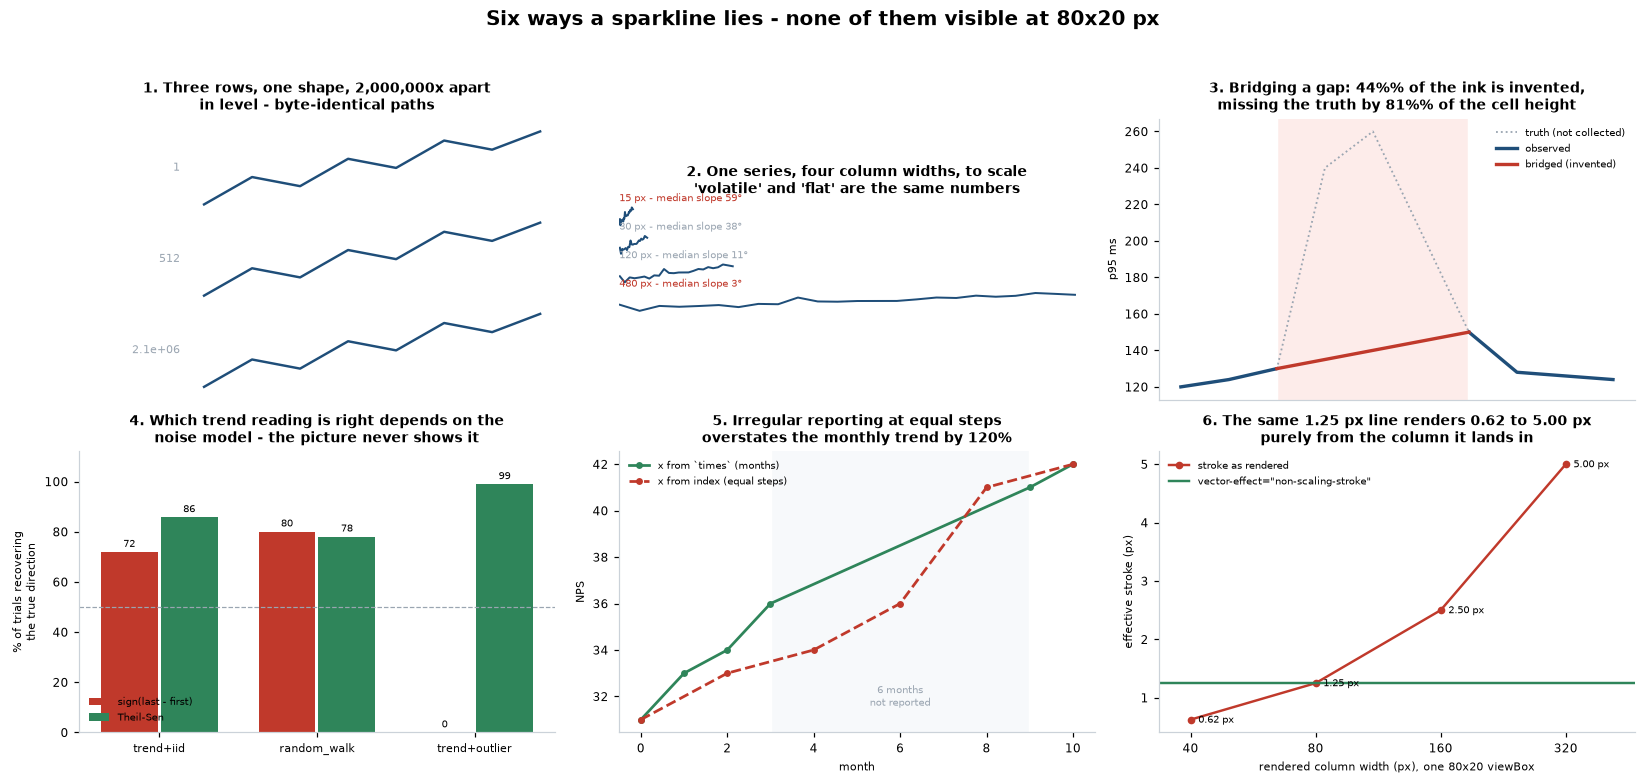

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

INK, BLUE, RED, GREY, GREEN = "#1f2933", "#1f4e79", "#c0392b", "#9aa5b1", "#2f855a"
plt.rcParams.update({"font.size": 8, "axes.titlesize": 9, "axes.titleweight": "bold",
                     "figure.dpi": 110, "axes.edgecolor": "#cbd2d9"})

fig, axes = plt.subplots(2, 3, figsize=(15, 7.2))
fig.suptitle(
    "Six ways a sparkline lies - none of them visible at 80x20 px",
    fontsize=13, fontweight="bold",
)

# (1) per-row autoscale collapses level
ax = axes[0][0]
shape = np.array([0, 3, 2, 5, 4, 7, 6, 8]) / 8.0
for k, lv in enumerate((1.0, 512.0, 2.0 ** 21)):
    v = lv * (1.0 + 0.5 * shape)
    ax.plot(np.arange(8), (v - v.min()) / (v.max() - v.min()) - k * 1.25, color=BLUE, lw=1.6)
    ax.text(-0.5, 0.5 - k * 1.25, "%.3g" % lv, ha="right", va="center", fontsize=7, color=GREY)
ax.set_xlim(-2.6, 7.3)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("1. Three rows, one shape, 2,000,000x apart\nin level - byte-identical paths")
for sp in ax.spines.values():
    sp.set_visible(False)

# (2) aspect ratio
ax = axes[0][1]
rng = np.random.default_rng(3)
vals = 100 + 0.9 * np.arange(24) + rng.normal(0, 2.2, 24)
s = Series("x", list(map(float, vals)))
dd = resolve_domain(s, "per_row")
for k, w in enumerate((15.0, 30.0, 120.0, 480.0)):
    p = build_path(s, dd, Geometry(width=w, height=20.0))
    ax.plot([q[0] for q in p.points], [-q[1] - k * 30 for q in p.points], color=BLUE, lw=1.3)
    ax.text(0, 6 - k * 30, "%.0f px - median slope %.0f°" % (w, banking_deg(p.points)),
            fontsize=6.8, color=RED if banking_deg(p.points) > 45 or banking_deg(p.points) < 8 else GREY)
ax.set_xlim(0, 500)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("2. One series, four column widths, to scale\n'volatile' and 'flat' are the same numbers")
for sp in ax.spines.values():
    sp.set_visible(False)

# (3) the bridged gap
ax = axes[0][2]
truth = np.array([120.0, 124, 130, 240, 260, 205, 150, 128, 126, 124])
xs = np.arange(10)
ax.plot(xs, truth, color=GREY, lw=1.2, ls=":", label="truth (not collected)")
ax.plot(xs[:3], truth[:3], color=BLUE, lw=2.2, label="observed")
ax.plot(xs[6:], truth[6:], color=BLUE, lw=2.2)
ax.plot([2, 6], [truth[2], truth[6]], color=RED, lw=2.2, label="bridged (invented)")
ax.axvspan(2.05, 5.95, color="#fdecea", zorder=0)
ax.set_title("3. Bridging a gap: 44%% of the ink is invented,\nmissing the truth by 81%% of the cell height")
ax.legend(frameon=False, fontsize=6.8, loc="upper right")
ax.set_xticks([])
ax.set_ylabel("p95 ms", fontsize=7)
ax.spines[["top", "right"]].set_visible(False)

# (4) trend estimator accuracy
ax = axes[1][0]
models = ["trend+iid", "random_walk", "trend+outlier"]
xp = np.arange(3)
ax.bar(xp - 0.19, [100 * trend[m]["endpoint"] for m in models], 0.36, color=RED, label="sign(last - first)")
ax.bar(xp + 0.19, [100 * trend[m]["robust"] for m in models], 0.36, color=GREEN, label="Theil-Sen")
ax.axhline(50, color=GREY, lw=0.8, ls="--")
for i, m in enumerate(models):
    for off, key in ((-0.19, "endpoint"), (0.19, "robust")):
        ax.text(i + off, 100 * trend[m][key] + 2, "%.0f" % (100 * trend[m][key]),
                ha="center", fontsize=6.8)
ax.set_xticks(xp)
ax.set_xticklabels(models, fontsize=7)
ax.set_ylim(0, 112)
ax.set_ylabel("% of trials recovering\nthe true direction", fontsize=7)
ax.set_title("4. Which trend reading is right depends on the\nnoise model - the picture never shows it")
ax.legend(frameon=False, fontsize=6.8, loc="lower left")
ax.spines[["top", "right"]].set_visible(False)

# (5) time vs index
ax = axes[1][1]
tt = np.array([0.0, 1, 2, 3, 9, 10])
nn = np.array([31.0, 33, 34, 36, 41, 42])
ax.plot(tt, nn, color=GREEN, lw=1.8, marker="o", ms=3.5, label="x from `times` (months)")
ax.plot(np.linspace(0, 10, 6), nn, color=RED, lw=1.8, marker="o", ms=3.5, ls="--",
        label="x from index (equal steps)")
ax.axvspan(3.05, 8.95, color="#f7f9fb", zorder=0)
ax.text(6.0, 31.6, "6 months\nnot reported", fontsize=6.8, color=GREY, ha="center")
ax.set_title("5. Irregular reporting at equal steps\noverstates the monthly trend by 120%")
ax.set_xlabel("month", fontsize=7)
ax.set_ylabel("NPS", fontsize=7)
ax.legend(frameon=False, fontsize=6.8, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)

# (6) stroke scaling
ax = axes[1][2]
widths = np.array([40.0, 80.0, 160.0, 320.0])
eff = 1.25 * widths / 80.0
cats = np.arange(4)
ax.plot(cats, eff, color=RED, marker="o", ms=4, lw=1.6, label="stroke as rendered")
ax.axhline(1.25, color=GREEN, lw=1.6, label='vector-effect="non-scaling-stroke"')
for c, e in zip(cats, eff):
    ax.annotate("%.2f px" % e, (c, e), textcoords="offset points", xytext=(5, -2), fontsize=6.8)
ax.set_xticks(cats)
ax.set_xticklabels(["%.0f" % w for w in widths])
ax.set_xlim(-0.25, 3.55)
ax.set_xlabel("rendered column width (px), one 80x20 viewBox", fontsize=7)
ax.set_ylabel("effective stroke (px)", fontsize=7)
ax.set_title("6. The same 1.25 px line renders 0.62 to 5.00 px\npurely from the column it lands in")
ax.legend(frameon=False, fontsize=6.8, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.savefig("sparkline_audit_nb.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

## 9. The verdict

`audit_table()` runs all four checks before anything is rendered and returns what the reader is
entitled to conclude. The sample table is deliberately nasty - every check fires on something.

In [16]:
rows = sample_table()
for m in ("per_row", "indexed"):
    print("=" * 78)
    print(audit_table(rows, mode=m, bridge_gaps=False).text())
    print()
print("=" * 78)
print("and the same table with the shortcut turned on:")
print(audit_table(rows, mode="per_row", bridge_gaps=True).text())

NOT COMPARABLE ACROSS ROWS (mode=per_row) - shape only
  note:    1 of 6 rows has missing values, rendered as breaks in the line
  note:    1 row has irregular time spacing; positions are taken from `times`, not the index (pass use_times=False to see what index spacing would have drawn)
  note:    1 constant row drawn as a flat mid-height line rather than expanded to fill the cell: uptime_pct
  note:    median rendered slope is 13 degrees at 80x20; slope judgement is most accurate near 45. Try banked_width() for a cell that suits the data

COMPARABLE ACROSS ROWS (mode=indexed)
  note:    1 of 6 rows has missing values, rendered as breaks in the line
  note:    1 row has irregular time spacing; positions are taken from `times`, not the index (pass use_times=False to see what index spacing would have drawn)
  note:    1 constant row drawn as a flat mid-height line rather than expanded to fill the cell: uptime_pct
  note:    median rendered slope is 0 degrees at 80x20; slope judgement is 

## 10. Try your own table

Uncomment, point it at a wide CSV (first column the label, the rest the periods), and read the
verdict before the picture.

In [17]:
# import pandas as pd
#
# df = pd.read_csv("your_metrics.csv")          # label column first, then one column per period
# label_col, value_cols = df.columns[0], df.columns[1:]
# rows = [
#     Series(
#         str(r[label_col]),
#         [None if pd.isna(r[c]) else float(r[c]) for c in value_cols],
#     )
#     for _, r in df.iterrows()
# ]
#
# # 1. read this BEFORE looking at any picture
# print(audit_table(rows, mode="indexed").text())
#
# # 2. then render. indexed is usually right for a table of heterogeneous metrics;
# #    shared when the rows are the same metric across segments.
# display(HTML(render_table(rows, mode="indexed", geom=Geometry(width=90, height=22))))
#
# # 3. and check what cell width the data actually wants
# for s in rows[:10]:
#     if len(s.present) > 1:
#         d = resolve_domain(s, "per_row")
#         print("%-24s wants %.0f px at 22 px tall"
#               % (s.label, banked_width(s, d, Geometry(width=90, height=22))))
print("ready - uncomment the block above and point it at your own CSV")

ready - uncomment the block above and point it at your own CSV


---

## What to take away

1. **Per-row autoscale does not compress level, it deletes it.** Eight rows spanning 2,000,000x
   emitted one path, byte for byte. If a table's sparklines are meant to be compared, the domain
   has to be shared or indexed - and the mode has to be printed, because the reader cannot see it.
2. **A sparkline's steepness is a CSS property.** The same 24 numbers ran from 59 degrees to 3
   degrees of median rendered slope across plausible column widths. Bank the cell to the data
   (`banked_width`) or accept that the layout is writing the conclusion.
3. **Never draw through a gap.** On the bundled outage, 44% of the drawn ink was invented and it
   missed the true path by 81% of the cell height, turning a spike-and-recovery into a clean rise.
4. **The trend reading a sparkline invites uses two points out of n**, and whether that is
   defensible depends on a noise model the picture cannot show you. Print a slope; do not imply one.
5. **Plot time on the time axis.** Equal index spacing made a six-month interval the steepest
   segment in the chart and overstated the monthly trend by 120%.
6. **At 20 pixels tall, `pad = stroke/2` and `non-scaling-stroke` are correctness, not polish** -
   and the byte budget lives in the wrapper, not the coordinates.

The honest summary: a sparkline is only ever half a statement. The other half is the number
printed beside it and the domain printed under it. That is why `render_table` emits all three and
`audit_table` runs first.

## Run the code

```bash
git clone https://github.com/phoebefu6/phoebe-the-builder
cd phoebe-the-builder/analytics-engineering-bi/sparkline-gen
pip install -r requirements.txt

python3 test_sparkline.py    # 80 tests over the core
python3 test_evidence.py     # 29 tests over the experiments above
python3 evidence.py          # every table in this notebook
python3 make_chart.py        # the six-panel audit figure
streamlit run app.py         # the interactive version
```

Part of [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) - Day 137,
Analytics Engineering & BI.